## Investigating the Invariant Mass vs Missing Mass Mismatch Issue

In [1]:
import pandas as pd
import numpy as np

from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer
from pathlib import Path
import vector

In [2]:
nuclear_map = NuclearDataMap()
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m

target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_spyral/e20020_analysis/solver_gas_16O.json")

ejectile_z = 2
ejectile_a = 4

# The incoming nucleus (the beam)
projectile_z = 8
projectile_a = 16


# The target nucleus
target_z = 2
target_a = 4

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a
print(residual_a,residual_z)

if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")

16 8


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
# fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 161.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]

# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")

Reaction: 4He(16O, 4He)16O
Target material: (Gas)4He1
Accelerator Beam energy: 161.0 MeV
Beam energy after IC (2 windows + gas): 161.0 MeV
Beam energy range in AT-TPC: 161.0-110.84634259864373 MeV


In [4]:

grammer = Histogrammer()
grammer.add_hist2d('ke_theta', (800, 1600), ((0.0, 180.0), (0.0, 80.0)))
grammer.add_hist2d('ke_phi', (800, 1600), ((0.0, 360.0), (0.0, 80.0)))
grammer.add_hist1d('ex', 120, (-5.0, 26.0))
grammer.add_hist1d('chisq', 100, (0.0, 1.0))
grammer.add_hist1d("vertex_z", 80, (0.0, 1.0))
grammer.add_hist2d("ex_vertex_z", (250, 500), ((-5.0, 20.0), (0.0, 1.0)))

## df from engine

In [5]:
event = 12

In [6]:
df = pd.read_parquet("/Users/pranjalsingh/Desktop/research_space_engine/e20020_engine/my_sim/output_16O_invariant/kinematics/o16a4a_700Torr_161.6MeV_15MeV.parquet")
df

,event,Z,A,isotope,energy,px,py,pz,vertex_x,vertex_y,vertex_z
0,0,2,4,4He,3727.379333,0.000000,0.000000,0.000000,-0.005088,-0.002020,0.571852
1,0,8,16,16O,15029.898045,0.000000,0.000000,2008.583380,-0.005088,-0.002020,0.571852
2,0,2,4,4He,3768.849815,152.662463,-24.595596,535.687846,-0.005088,-0.002020,0.571852
3,0,8,16,16O,14988.427562,-152.662463,24.595596,1472.895534,-0.005088,-0.002020,0.571852
4,0,2,4,4He,3752.042791,-201.559856,53.724589,375.440680,-0.005088,-0.002020,0.571852
...,...,...,...,...,...,...,...,...,...,...,...
99995,9999,6,12,12C,11245.072902,-1.741393,10.133982,1184.425803,-0.007013,0.007227,0.972257
99996,9999,2,4,4He,3748.512879,-22.801332,-27.255365,395.890591,-0.007013,0.007227,0.972257
99997,9999,4,8,8Be,7496.560023,21.059939,37.389347,788.535212,-0.007013,0.007227,0.972257
99998,9999,2,4,4He,3747.473810,8.495239,1.690525,387.463855,-0.007013,0.007227,0.972257


In [7]:
filtered_df = df[(df["event"] == event) & (df["Z"]== 2)]

unique_events = np.unique(df["event"])

## df from Solver (decay and target)

In [8]:
# run = 0

# """Decay Kinematics
# """
# df_decay = pd.read_parquet(f"/Volumes/researchEXT/O16/all_analysis_spyralv1.0/simulated_16O_decay/InterpSolver/run_{run:04d}_4He.parquet")
# brho_decay = df_decay["brho"]
# momentum_decay = (
#             brho_decay
#             * float(ejectile.Z)
#             * QBRHO_2_P
#         )

# px_decay = momentum_decay * np.sin(df_decay["polar"]) * np.cos(df_decay["azimuthal"])
# py_decay = momentum_decay * np.sin(df_decay["polar"]) * np.sin(df_decay["azimuthal"])
# pz_decay = momentum_decay * np.cos(df_decay["polar"])

# df_decay["px"] = px_decay
# df_decay["py"] = py_decay
# df_decay["pz"] = pz_decay

# energy_decay = np.sqrt(
#             momentum_decay**2.0 + ejectile.mass**2.0
#         )

# df_decay["energy"] = energy_decay


# """Target Kinematics
# """
# df_target = pd.read_parquet(f"/Volumes/researchEXT/O16/all_analysis_spyralv1.0/simulated_16O_target/InterpSolver/run_{run:04d}_4He.parquet")
# brho_target = df_target["brho"]
# momentum_target = (
#             brho_target
#             * float(ejectile.Z)
#             * QBRHO_2_P
#         )

# px_target = momentum_target * np.sin(df_target["polar"]) * np.cos(df_target["azimuthal"])
# py_target = momentum_target * np.sin(df_target["polar"]) * np.sin(df_target["azimuthal"])
# pz_target = momentum_target * np.cos(df_target["polar"])

# df_target["px"] = px_target
# df_target["py"] = py_target
# df_target["pz"] = pz_target

# energy_target = np.sqrt(
#             momentum_target**2.0 + ejectile.mass**2.0
#         )

# df_target["energy"] = energy_target



# filtered_df_decay = df_decay[(df_decay["event"] == event)]
# filtered_df_target = df_target[(df_target["event"] == event)]


In [9]:
filtered_df

,event,Z,A,isotope,energy,px,py,pz,vertex_x,vertex_y,vertex_z
120,12,2,4,4He,3727.379333,0.000000,0.000000,0.000000,0.004256,-0.00365,0.989896
122,12,2,4,4He,3755.975625,-35.506053,74.609385,455.158177,0.004256,-0.00365,0.989896
124,12,2,4,4He,3747.085139,-152.746123,34.563426,350.377428,0.004256,-0.00365,0.989896
126,12,2,4,4He,3746.437290,83.069492,-17.165280,367.750577,0.004256,-0.00365,0.989896
128,12,2,4,4He,3741.764887,38.185499,-54.249464,321.008784,0.004256,-0.00365,0.989896
129,12,2,4,4He,3743.433683,66.997185,-37.758067,337.683266,0.004256,-0.00365,0.989896


In [10]:
# filtered_df_decay

In [11]:
# filtered_df_target

## Total energy

### What the sum should be (engine)

In [12]:
# total_inv_engine = filtered_df['energy'].tail(4).sum()
# print(total_inv_engine)

### What is sum is (spyral)

In [13]:
# total_inv_spyral = filtered_df_decay['energy'].tail(4).sum()
# print(total_inv_spyral)

## Invariant energy

### engine

In [14]:
# px_eng_tot = filtered_df["px"].tail(4).sum()
# py_eng_tot = filtered_df["py"].tail(4).sum()
# pz_eng_tot = filtered_df["pz"].tail(4).sum()

# p_eng_tot = np.sqrt(
#             px_eng_tot**2
#             + py_eng_tot**2
#             + pz_eng_tot**2
#         )

# inv_mass_eng = np.sqrt(
#             total_inv_engine**2 - p_eng_tot**2
#         )

# inv_energy_eng = inv_mass_eng - projectile.mass #projectile mass 16O

# print(f"Engine 16O excitation energy: {inv_energy_eng} MeV")


### spyral

In [15]:
# px_spy_tot = filtered_df_decay["px"].tail(4).sum()
# py_spy_tot = filtered_df_decay["py"].tail(4).sum()
# pz_spy_tot = filtered_df_decay["pz"].tail(4).sum()

# p_spy_tot = np.sqrt(
#             px_spy_tot**2
#             + py_spy_tot**2
#             + pz_spy_tot**2
#         )

# inv_mass_spy = np.sqrt(
#             total_inv_spyral**2 - p_spy_tot**2
#         )

# inv_energy_spy = inv_mass_spy - projectile.mass #projectile mass 16O

# print(f"Spyral 16O excitation energy: {inv_energy_spy} MeV")

## Missing mass

### engine

In [16]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

vertices_eng = filtered_df[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy() 
print(f"Verticies: {vertices_eng}")
distance_eng = np.linalg.norm(vertices_eng, axis=1)

projectile_ke_eng = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_eng))

projectile_vector_eng = vector.array({
        "px": np.zeros(len(projectile_ke_eng)),
        "py": np.zeros(len(projectile_ke_eng)),
        "pz": np.sqrt(projectile_ke_eng * (projectile_ke_eng + 2.0 * projectile.mass)),
        "E": projectile_ke_eng + projectile.mass
    })


ejectile_vector_eng = vector.array({
    "px": filtered_df["px"].to_numpy(),
    "py": filtered_df["py"].to_numpy(),
    "pz": filtered_df["pz"].to_numpy(),
    "E": filtered_df["energy"].to_numpy()
})
residual_vector = (target_vector + projectile_vector_eng - ejectile_vector_eng)
ex_eng = residual_vector.mass - residual.mass

print(f"Engine 16O excitation energy (missing): {ex_eng[1]} MeV")


Verticies: [[ 0.00425584 -0.00364982  0.98989602]
 [ 0.00425584 -0.00364982  0.98989602]
 [ 0.00425584 -0.00364982  0.98989602]
 [ 0.00425584 -0.00364982  0.98989602]
 [ 0.00425584 -0.00364982  0.98989602]
 [ 0.00425584 -0.00364982  0.98989602]]
Engine 16O excitation energy (missing): 19.800869689941464 MeV


In [33]:
missing_mass_eng = []

for event_num in unique_events:
    filtered_df = df[(df["event"] == event_num) & (df["Z"]== 2)]
    target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
    })

    # vertices_eng = filtered_df[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy() 
    # print(f"Verticies: {vertices_eng}")
    distance_eng = filtered_df["vertex_z"].to_numpy()

    projectile_ke_eng = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_eng))

    projectile_vector_eng = vector.array({
            "px": np.zeros(len(projectile_ke_eng)),
            "py": np.zeros(len(projectile_ke_eng)),
            "pz": np.sqrt(projectile_ke_eng * (projectile_ke_eng + 2.0 * projectile.mass)),
            "E": projectile_ke_eng + projectile.mass
        })


    ejectile_vector_eng = vector.array({
        "px": filtered_df["px"].to_numpy(),
        "py": filtered_df["py"].to_numpy(),
        "pz": filtered_df["pz"].to_numpy(),
        "E": filtered_df["energy"].to_numpy()
    })
    
    total_momentum = np.sqrt((filtered_df["px"].to_numpy())**2 + (filtered_df["py"].to_numpy())**2 + (filtered_df["pz"].to_numpy())**2)
    kinetic_energy = np.sqrt(total_momentum**2.0 + ejectile.mass**2.0) - ejectile.mass
    
    polar = np.arccos((filtered_df["pz"].to_numpy())/total_momentum)
    
    residual_vector = (target_vector + projectile_vector_eng - ejectile_vector_eng)
    ex_eng = residual_vector.mass - residual.mass
    missing_mass_eng.append(ex_eng[1])
    
    grammer.fill_hist2d('ke_theta', np.rad2deg(polar), kinetic_energy)
    grammer.fill_hist1d('ex', ex_eng[1])

/var/folders/5q/ngq_6gg50c35p7kqrqgnwmzw0000gs/T/ipykernel_95469/4038147400.py:36: RuntimeWarning: invalid value encountered in divide
  polar = np.arccos((filtered_df["pz"].to_numpy())/total_momentum)


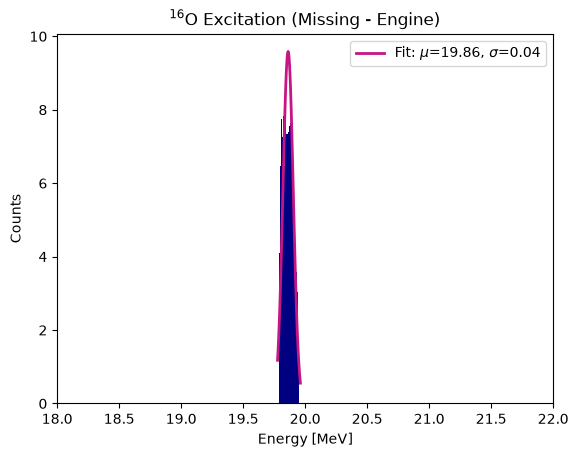

In [42]:
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, ax = plt.subplots()
counts, bins, patches =  ax.hist(missing_mass_eng, bins=70, color='navy',density=True)

mu, sigma = norm.fit(missing_mass_eng)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)

ax.plot(x, p, color='mediumvioletred', linewidth=2, label=f'Fit: $\mu$={mu:.2f}, $\sigma$={sigma:.2f}')
ax.legend()

plt.title(r"$^{16}$O Excitation (Missing - Engine)")
plt.xlabel("Energy [MeV]")
plt.ylabel("Counts")
plt.xlim(18,22)
plt.show()

In [35]:
# target_vector = vector.array({
#     "px": [0.0],
#     "py": [0.0],
#     "pz": [0.0],
#     "E": [target.mass]
# })

# # vertices_eng = filtered_df[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy()
# # print(f"Verticies: {vertices_eng}")
# distance_eng = filtered_df[['vertex_z']].to_numpy()

# projectile_ke_eng = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_eng))

# projectile_vector_eng = vector.array({
#         "px": np.zeros(len(projectile_ke_eng)),
#         "py": np.zeros(len(projectile_ke_eng)),
#         "pz": np.sqrt(projectile_ke_eng * (projectile_ke_eng + 2.0 * projectile.mass)),
#         "E": projectile_ke_eng + projectile.mass
#     })


# ejectile_vector_eng = vector.array({
#     "px": filtered_df["px"].to_numpy(),
#     "py": filtered_df["py"].to_numpy(),
#     "pz": filtered_df["pz"].to_numpy(),
#     "E": filtered_df["energy"].to_numpy()
# })
# residual_vector = (target_vector + projectile_vector_eng - ejectile_vector_eng)
# ex_eng = residual_vector.mass - residual.mass

# print(f"Engine 16O excitation energy (missing): {ex_eng[1]} MeV")

### spyral

In [36]:
# target_vector = vector.array({
#     "px": [0.0],
#     "py": [0.0],
#     "pz": [0.0],
#     "E": [target.mass]
# })

# vertices_spy = filtered_df_target[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy()
# print(f"Verticies: {vertices_spy}")
# vertices_spy = np.concatenate((vertices_spy,vertices_spy),axis=0) #just did so I can call spyral functions with an array
# distance_spy = np.linalg.norm(vertices_spy, axis=1)

# projectile_ke_spy = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_spy))

# projectile_vector_spy = vector.array({
#         "px": np.zeros(len(projectile_ke_spy)),
#         "py": np.zeros(len(projectile_ke_spy)),
#         "pz": np.sqrt(projectile_ke_spy * (projectile_ke_spy + 2.0 * projectile.mass)),
#         "E": projectile_ke_spy + projectile.mass
#     })

# brho = filtered_df_target['brho'].to_numpy()
# brho = np.concatenate((brho,brho),axis=0).flatten() #just did so I can call spyral functions with an array
# momentum = brho * float(ejectile.Z) * QBRHO_2_P

# polar = filtered_df_target['polar'].to_numpy()
# polar = np.concatenate((polar,polar),axis=0).flatten()
# az = filtered_df_target['azimuthal'].to_numpy()
# az = np.concatenate((az,az),axis=0).flatten()

# ejectile_vector_spy = vector.array({
#         "px": momentum * np.sin(polar) * np.cos(az),
#         "py": momentum * np.sin(polar) * np.sin(az),
#         "pz": momentum * np.cos(polar),
#         "E": np.sqrt(momentum**2.0 + ejectile.mass**2.0)
#     })



# residual_vector = (target_vector + projectile_vector_spy - ejectile_vector_spy)

# ex_spy = residual_vector.mass - residual.mass

# print(f"Engine 16O excitation energy (missing): {ex_spy[0]} MeV")

### what's the difference between engine and spyral?

#### ejectile vector

In [37]:
# print(ejectile_vector_eng[1])
# print(ejectile_vector_spy[0])

#### target vector is the same for both

#### projectile vector

In [38]:
# print(projectile_vector_eng[1])
# print(projectile_vector_spy[0])

In [39]:
# print(ejectile.mass)

## Energy

(0.0, 80.0)

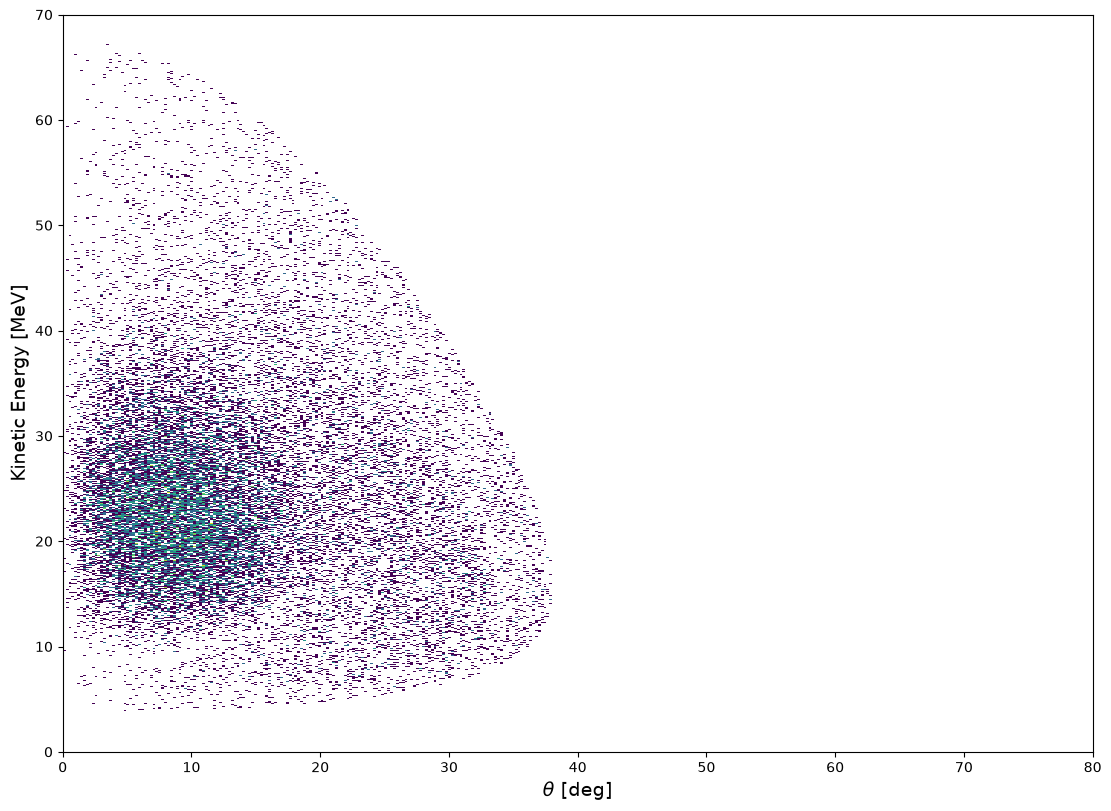

In [40]:
ke_theta = grammer.get_hist2d("ke_theta")
ke_phi = grammer.get_hist2d("ke_phi")
fig, ax = plt.subplots(1,1, constrained_layout=True)
mesh = ax.pcolormesh(ke_theta.x_bins, ke_theta.y_bins, ke_theta.counts, norm="log")
# ax.set_title("Kinetic Energy vs. Polar Angle")
ax.set_xlabel(r"$\theta$ [deg]", fontsize = 14)
ax.set_ylabel("Kinetic Energy [MeV]",fontsize = 14)
# fig.colorbar(mesh, ax=ax)
# for idx, ex in enumerate(residual_excitations):
#     ax.plot(np.rad2deg(eject_kinematics[idx, :len(cm_angle_range), 0]), eject_kinematics[idx, :len(cm_angle_range), 1], label=f"Ex={ex:02} Upper Edge")
#     # Fill idea thanks to D. Ramirez
#     ax.fill(np.rad2deg(eject_kinematics[idx, :, 0]), eject_kinematics[idx, :, 1], label=f"Ex={ex:02} Band", alpha=0.2)
fig.set_figheight(8.0)
fig.set_figwidth(11.0)
ax.set_ylim(0,70)
ax.set_xlim(0,80)
# ax.legend(fontsize=14)